# Курсовая работа

## Приближенные методы решения задачи коммивояжера

### Imports

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from time import perf_counter
from IPython.display import clear_output
import os
import sys
import elkai
import pickle

In [2]:
def graph_setup():
    sns.set_style("whitegrid")
    sns.set_context("notebook", font_scale=1.2)
    plt.rcParams['figure.figsize'] = [8, 6]
    plt.rcParams['figure.dpi'] = 100

graph_setup()

### Генерация графа на плоскости

In [3]:
n_vertices = 5
density = 1.0

cell_width = 5
random_state = 42
rs = np.random.RandomState(random_state)

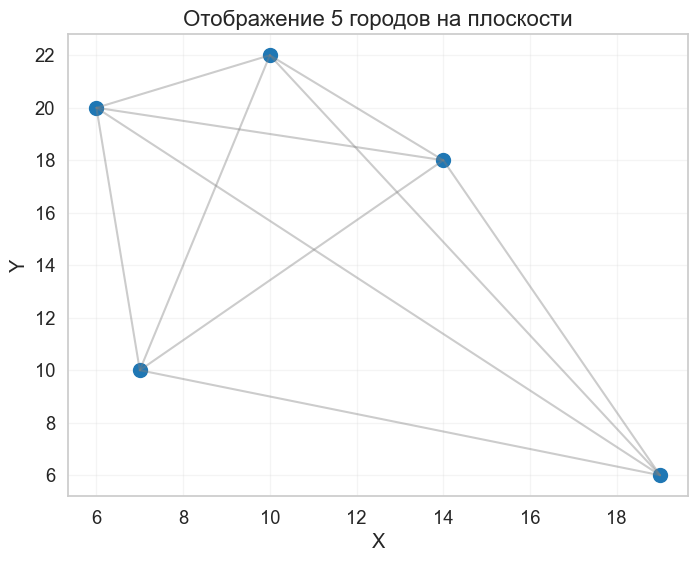

In [4]:
xs = rs.randint(cell_width * n_vertices, size=n_vertices)
ys = rs.randint(cell_width * n_vertices, size=n_vertices)

for i in range(n_vertices):
    for j in range(i + 1, n_vertices):
        plt.plot([xs[i], xs[j]], [ys[i], ys[j]], color='gray', alpha=0.4)

plt.scatter(xs, ys, s=100)
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Отображение {n_vertices} городов на плоскости', fontsize=16)
plt.grid(True, alpha=0.2)
plt.show()

In [5]:
xs, ys

(array([ 6, 19, 14, 10,  7], dtype=int32),
 array([20,  6, 18, 22, 10], dtype=int32))

In [6]:
def compute_euclidian(x1, x2, y1, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

def euclidian_matrix(xs, ys):
    n_vertices = xs.shape[0]
    triu_matrix = np.zeros((n_vertices, n_vertices))
    for i in range(n_vertices):
        for j in range(i + 1, n_vertices):
            triu_matrix[i, j] = compute_euclidian(xs[i], xs[j], ys[i], ys[j])
    matrix = triu_matrix + triu_matrix.T
    return matrix

def generate_matrix(n_vertices, cell_width=5, rs=None, xy=False):
    if rs is None:
        rs = np.random.RandomState(None)
    xs = rs.randint(cell_width * n_vertices, size=n_vertices)
    ys = rs.randint(cell_width * n_vertices, size=n_vertices)
    matrix = euclidian_matrix(xs, ys)
    if xy:
        return matrix, xs, ys
    return matrix

def sparse_matrix(n_vertices, density, cell_width=5, rs=None):
    if rs is None:
        rs = np.random.RandomState(None)
    matrix = generate_matrix(n_vertices, cell_width=cell_width, rs=rs)
    triu = np.triu(matrix, 1)
    mask_del = rs.choice([True, False], p=[1-density, density], size=triu.shape)
    triu[mask_del] = 0
    triu += triu.T
    return triu

def get_density(matrix):
    n_vertices = matrix.shape[0]
    triu = np.triu(matrix, 1)
    edges = np.count_nonzero(triu)
    max_edges = (n_vertices) * (n_vertices - 1) // 2
    return edges / max_edges
    

In [7]:
rs = np.random.RandomState(random_state)
adj_matrix = generate_matrix(n_vertices=5, rs=rs)


if False:
    rs = np.random.RandomState(random_state)
    sparsed_matrix = sparse_matrix(n_vertices=5, density=0.9, rs=rs)
    adj_matrix = sparsed_matrix

In [8]:
adj_matrix

array([[ 0.        , 19.10497317,  8.24621125,  4.47213595, 10.04987562],
       [19.10497317,  0.        , 13.        , 18.35755975, 12.64911064],
       [ 8.24621125, 13.        ,  0.        ,  5.65685425, 10.63014581],
       [ 4.47213595, 18.35755975,  5.65685425,  0.        , 12.36931688],
       [10.04987562, 12.64911064, 10.63014581, 12.36931688,  0.        ]])

In [9]:
diagonal = adj_matrix.copy()
np.fill_diagonal(diagonal, np.inf)
pd.DataFrame(diagonal).round(2)

,0,1,2,3,4
0,inf,19.10,8.25,4.47,10.05
1,19.10,inf,13.00,18.36,12.65
2,8.25,13.00,inf,5.66,10.63
3,4.47,18.36,5.66,inf,12.37
4,10.05,12.65,10.63,12.37,inf


In [10]:
def plot_graph(graph, cycle_edges=None, etalon_edges=None, title='Граф', color='blue'):
    pos = nx.kamada_kawai_layout(graph)
    nx.draw(graph, pos, with_labels=True, node_color='lightblue', node_size=500, font_size=12, edge_color='gray')

    if etalon_edges is not None:
        nx.draw_networkx_edges(graph, pos, edgelist=etalon_edges, width=3, edge_color='orange', alpha=0.6)

    if cycle_edges is not None:
        nx.draw_networkx_edges(graph, pos, edgelist=cycle_edges, width=5, style=':', edge_color=color)

    edge_labels = nx.get_edge_attributes(graph, 'weight')
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=10)

    plt.title(title)
    plt.show()

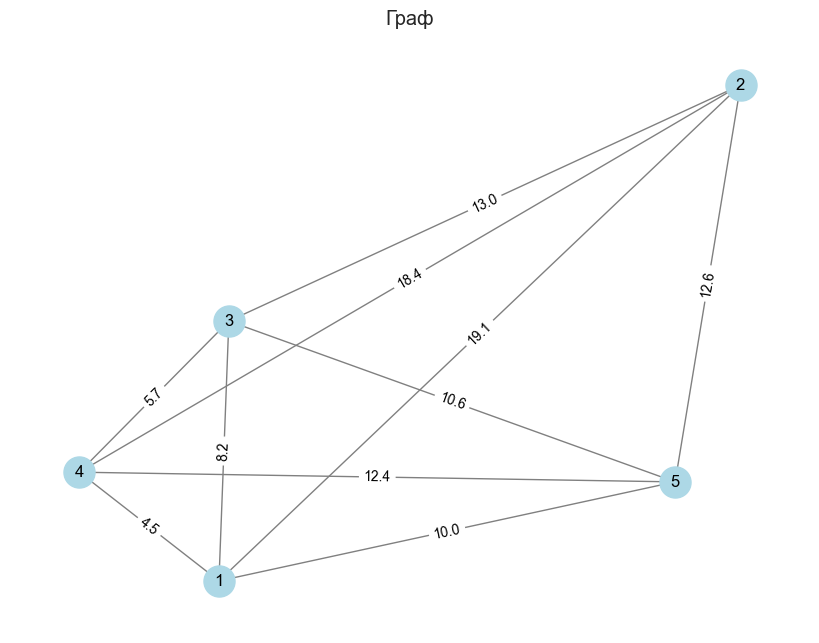

In [11]:
graph = nx.from_numpy_array(np.round(adj_matrix, 1))
graph = nx.relabel_nodes(graph, {i: i+1 for i in range(n_vertices)})
plot_graph(graph) 

### Генерация данных

In [12]:
def get_data(N_nodes, avg_iter=20, random_state=42):
    graphs = []
    rs = np.random.RandomState(random_state)
    for n_vertices in N_nodes:
        node_graphs = []
        for _ in range(avg_iter):
            matrix = generate_matrix(n_vertices, rs=rs)
            node_graphs.append(matrix)
        node_graphs = np.array(node_graphs, dtype=float)
        graphs.append(node_graphs)
    return graphs

In [13]:
%%time

get = False
if get:

    N_nodes = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200, 300, 500, 1000]
    graphs = get_data(N_nodes)
    print(f'Размер данных: {sys.getsizeof(graphs) / 1024:.2f} КБайт')

    N_nodes = []
    for node_graphs in graphs:
        N_nodes.append(node_graphs.shape[1])
    print(N_nodes)

CPU times: total: 0 ns
Wall time: 0 ns


### Метод ближайшего соседа (МБС)

In [14]:
class NearestNeighbor:
    def __init__(self, info=False):
        self.base_node = 0
        self.info = info
        
        self.time_ = None
        self.best_cycle_ = None
        self.best_length_ = None
        self.result_ = None

    def fit(self, matrix):
        start_time = perf_counter()
        
        n_vertices = matrix.shape[0]
        visited = np.zeros_like(matrix[0], dtype=bool)
        cycle = []
        weights = []
        current_node = self.base_node
        last_iter = n_vertices - 1

        for i in range(n_vertices):

            if i == last_iter:
                visited[self.base_node] = False
            edges = matrix[current_node].astype(float)
            edges[visited] = np.inf
            edges[edges == 0] = np.inf
            next_node = np.argmin(edges)

            if i == last_iter and next_node != self.base_node:
                if self.info:
                    print('Нет допустимых узлов!')
                self.result_ = 1
                end_time = perf_counter()
                self.time_ = int((end_time - start_time) * 1000)
                return
            if np.isinf(edges[next_node]):
                if self.info:
                    print('Нет допустимых узлов!')
                self.result_ = 1
                end_time = perf_counter()
                self.time_ = int((end_time - start_time) * 1000)
                return
            else:
                visited[current_node] = True
                cycle.append(current_node)
                weights.append(edges[next_node])
                current_node = next_node
        
        self.best_cycle_ = np.array(cycle).astype(int)
        self.best_length_ = np.sum(np.array(weights)).astype(int)
        end_time = perf_counter()
        self.time_ = int((end_time - start_time) * 1000)
        
        if self.info:
            print('Поиск успешно завершен!')
        self.result_ = 0

    def get(self):
        return self.best_cycle_, self.best_length_, self.result_, self.time_


In [15]:
%%time
nn_model = NearestNeighbor(info=True)
nn_model.fit(adj_matrix)
nn_cycle, nn_dist, nn_result, nn_time = nn_model.get()

Поиск успешно завершен!
CPU times: total: 0 ns
Wall time: 999 μs


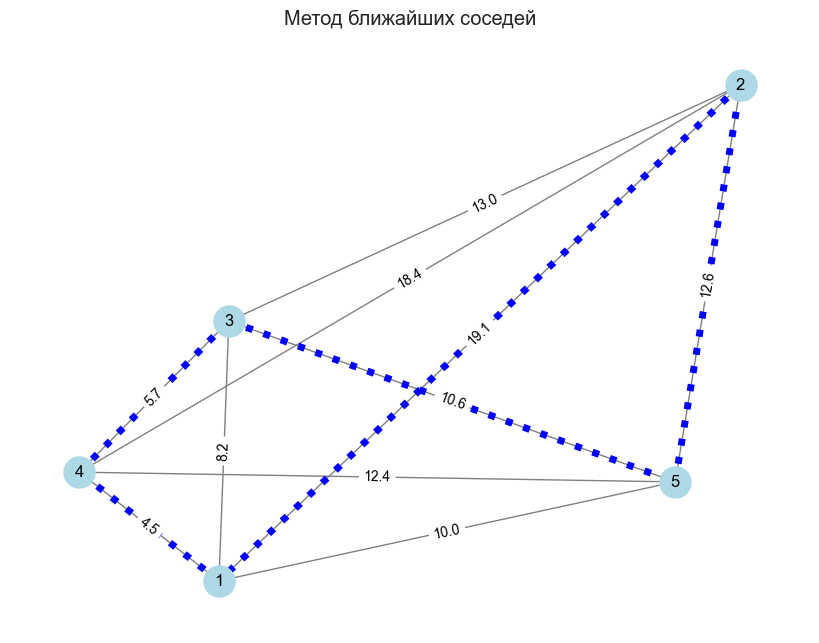

In [16]:
if nn_cycle is not None:
    nn_edges = [(int(nn_cycle[i]) + 1, int(nn_cycle[(i + 1) % n_vertices]) + 1) for i in range(n_vertices)]

plot_graph(graph, nn_edges, title='Метод ближайших соседей')

In [17]:
def compute_error(length, etalon_length):
    if length is None or etalon_length is None:
        return None
    return (length - etalon_length) / etalon_length * 100

def check_perfomance(best_length, time, n_vertices=n_vertices, density=density, etalon_dist=None, model_name=None):
    if model_name is not None:
        print(f'=== {model_name} ===')
    print(f'Число вершин: {n_vertices}')
    print(f'Плотность графа: {density:.2f}')
    if best_length is None:
        print(f'Оптимальный маршрут не найден.')
    else:
        print(f'Длина найденного цикла: {int(best_length)}')
        if etalon_dist is not None:
            print(f'Минимальная длина: {etalon_dist}')
            print(f'Отклонение: {compute_error(best_length, etalon_dist):.2f} %')
        
    if time < 1000:
        print(f'Время исполнения: {time} мс')
    else:
        print(f'Время исполнения: {time // 1000} c')

In [18]:
check_perfomance(nn_dist, nn_time, model_name='Метод ближайших соседей')

=== Метод ближайших соседей ===
Число вершин: 5
Плотность графа: 1.00
Длина найденного цикла: 52
Время исполнения: 0 мс


### Алгоритм колонии муравьев (АКМ)

In [19]:
class Ant:
    def __init__(self, n_vertices, start_node, random_state=None):
        self.n_vertices = n_vertices
        self.reset(start_node)
        self.rs = np.random.RandomState(random_state)
    
    def reset(self, node):
        self.start_node = node
        self.current_node = node
        self.length = 0.0
        self.visited = np.zeros(self.n_vertices, dtype=bool)
        self.visited[self.current_node] = True
        self.cycle = [self.current_node]
    
    def choose_next_node(self, pheromone_row, visibility_row):
        product = pheromone_row * visibility_row
        product[self.visited] = 0.0
        total = np.sum(product)
        if total == 0:
            return None
        probas = product / total
        next_node = self.rs.choice(self.n_vertices, p=probas)
        return next_node
    
    def make_step(self, next_node, distance):
        self.length += distance
        self.current_node = next_node
        self.visited[self.current_node] = True
        self.cycle.append(self.current_node)

In [20]:
class AntColony:
    def __init__(self, etalon_dist=None, random_state=None, max_iter=100, stop_iter=15, 
                 alpha=1, beta=2, rho=0.5, Q=10, info=False, init_cycle=None):
        self.rs = np.random.RandomState(random_state)
        self.random_state = random_state
        self.max_iter = max_iter
        self.alpha = alpha
        self.beta = beta
        self.rho = rho
        self.Q = Q
        self.info = info
        self.stop_iter = stop_iter
        self.etalon_dist = etalon_dist
        self.init_cycle = init_cycle
        
        self.best_cycle_ = None
        self.best_length_ = None
        self.result_ = None
        self.time_ = None
    
    def fit(self, matrix):
        start_time = perf_counter()
        self.n_vertices = matrix.shape[0]
        best_cycle = None
        best_length = np.inf
        
        pheromone = np.ones((self.n_vertices, self.n_vertices)) * 1e-6
        if self.init_cycle is not None:
            for i in range(self.n_vertices):
                from_node = self.init_cycle[i]
                to_node = self.init_cycle[(i+1) % self.n_vertices]
                pheromone[from_node, to_node] = 1e-2
                pheromone[to_node, from_node] = 1e-2
        
        visibility = np.divide(1.0, matrix, out=np.zeros_like(matrix, dtype=float), where=(matrix > 0))
        
        ants = [Ant(self.n_vertices, i, random_state=self.random_state) for i in range(self.n_vertices)]
        
        stop_count = 0
        for iteration in range(self.max_iter):
            if self.info and iteration == 10:
                delta_time = perf_counter() - start_time
                total_info_steps = self.max_iter // 10 + 1
                total_time = total_info_steps * delta_time
            
            if self.info and iteration > 0 and iteration % 10 == 0:
                current_time = perf_counter()
                passed = current_time - start_time
                remained = total_time - passed
                print(f'Итeрация: {iteration} | \
                        Прошло секунд: {passed:.0f} | \
                        Осталось секунд: {remained:.0f}')
                if self.etalon_dist is not None:
                    diff = (best_length - etalon_dist) / etalon_dist * 100 if etalon_dist is not None else 100.0
                    print(f'Отклонение: {diff:.2f} %')
                clear_output(wait=True)
                
            found_cycles = []
            found_lengths = []
            old_length = best_length
            
            for ant in ants:
                start_node = rs.choice(self.n_vertices)
                ant.reset(start_node)
                
                for step in range(n_vertices - 1):
                    pheromone_row = pheromone[ant.current_node] ** self.alpha
                    visibility_row = visibility[ant.current_node] ** self.beta
                    next_node = ant.choose_next_node(pheromone_row, visibility_row)
                    if next_node is None:
                        break
                        
                    distance = matrix[ant.current_node, next_node]
                    ant.make_step(next_node, distance)
                else:
                    closing_distance = matrix[ant.current_node, start_node]
                    if closing_distance > 0:
                        ant.length += closing_distance
                        ant.cycle.append(start_node)
                        found_cycles.append(ant.cycle)
                        found_lengths.append(ant.length)
                        
                        if ant.length < best_length:
                            best_cycle = ant.cycle.copy()
                            best_length = ant.length.copy()
            
            if best_length < old_length:
                stop_count = 0
            else:
                stop_count += 1
            
            if stop_count >= self.stop_iter:
                if self.info:
                    print('Ранняя остановка.')
                break
            
            pheromone *= (1 - self.rho)
            for cycle, length in zip(found_cycles, found_lengths):
                for i in range(n_vertices):
                    from_node = cycle[i]
                    to_node = cycle[i + 1]
                    delta = self.Q / length
                    pheromone[from_node, to_node] += delta
                    pheromone[to_node, from_node] += delta
            
                    
        if best_cycle is None:
            self.result_ = 1
        else:
            self.best_cycle_ = np.array(best_cycle[:-1]).astype(int)
            self.best_length_ = best_length
            self.result_ = 0
        
        end_time = perf_counter()
        self.time_ = int((end_time - start_time) * 1000)
        
        if self.info and self.result_ == 0:
            print('Алгоритм колонии муравьев успешно завершен!')
        elif self.info and self.result_ == 1:
            print('Нет допустимых узлов!')
            
    def get(self):
        return self.best_cycle_, self.best_length_, self.result_, self.time_

In [21]:
%%time
aco_model = AntColony(info=True, max_iter=100)
aco_model.fit(adj_matrix)

Ранняя остановка.
Алгоритм колонии муравьев успешно завершен!
CPU times: total: 78.1 ms
Wall time: 69.1 ms


In [22]:
aco_cycle, aco_dist, aco_result, aco_time = aco_model.get()

check_perfomance(aco_dist, aco_time, model_name='Алгоритм колонии муравьев')

=== Алгоритм колонии муравьев ===
Число вершин: 5
Плотность графа: 1.00
Длина найденного цикла: 45
Время исполнения: 68 мс


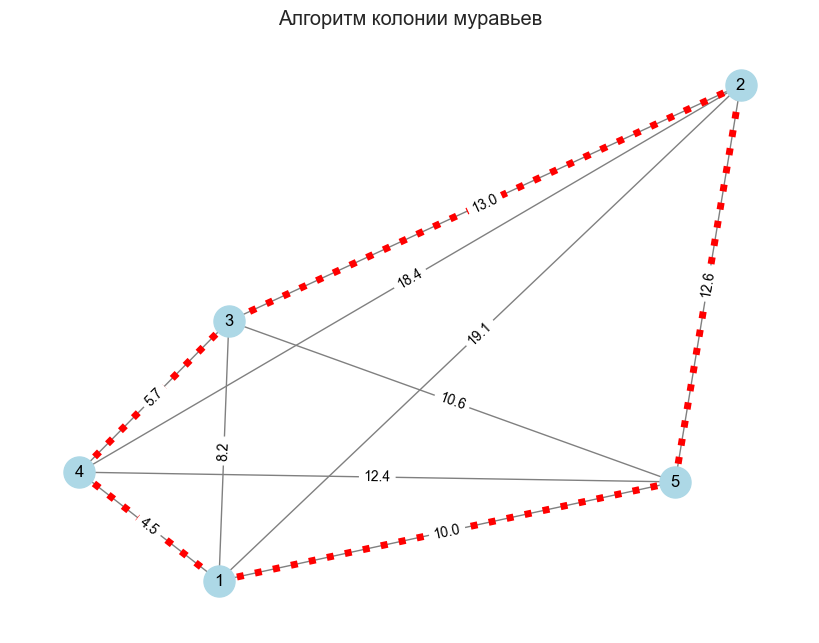

In [23]:
if aco_cycle is not None:
    aco_edges = [(int(aco_cycle[i]) + 1, int(aco_cycle[(i + 1) % n_vertices]) + 1) for i in range(n_vertices)]

plot_graph(graph, aco_edges, title='Алгоритм колонии муравьев', color='red')

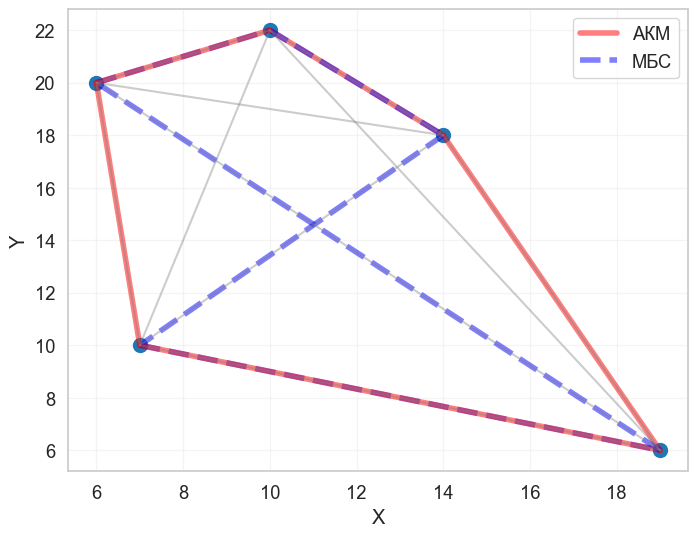

In [24]:
plt.scatter(xs, ys, s=100)
for i in range(n_vertices):
    current_node, next_node = aco_cycle[i], aco_cycle[(i+1) % n_vertices]
    x1, x2, y1, y2 = xs[current_node], xs[next_node], ys[current_node], ys[next_node]
    x, y = (x1, x2), (y1, y2)
    if i == 0:
        label = 'АКМ'
    else:
        label = '_nolegend_'
    plt.plot(x, y, color='red', alpha=0.5, linewidth=4, label=label)
    
    current_node, next_node = nn_cycle[i], nn_cycle[(i+1)% n_vertices]
    x1, x2, y1, y2 = xs[current_node], xs[next_node], ys[current_node], ys[next_node]
    x, y = (x1, x2), (y1, y2)
    if i == 0:
        label = 'МБС'
    else:
        label = '_nolegend_'
    plt.plot(x, y, color='blue', alpha=0.5, linewidth=4, label=label, linestyle='--')
    
for i in range(n_vertices):
    for j in range(i+1, n_vertices):
        plt.plot([xs[i], xs[j]], [ys[i], ys[j]], color='gray', alpha=0.4)

        
plt.legend(loc='best')
plt.xlabel('X')
plt.ylabel('Y')
# plt.title(f'Маршруты приближенных алгоритмов')
plt.grid(True, alpha=0.2)
plt.show()

### Отображение маршрута МБС через 1000 городов

In [119]:
n_vertices = 1000

cell_width = 5
random_state = 42
rs = np.random.RandomState(random_state)

matrix, xs, ys = generate_matrix(n_vertices, rs=rs, xy=True)

In [120]:
nn_model = NearestNeighbor(info=True)
nn_model.fit(matrix)
nn_cycle, nn_dist, nn_result, nn_time = nn_model.get()

Поиск успешно завершен!


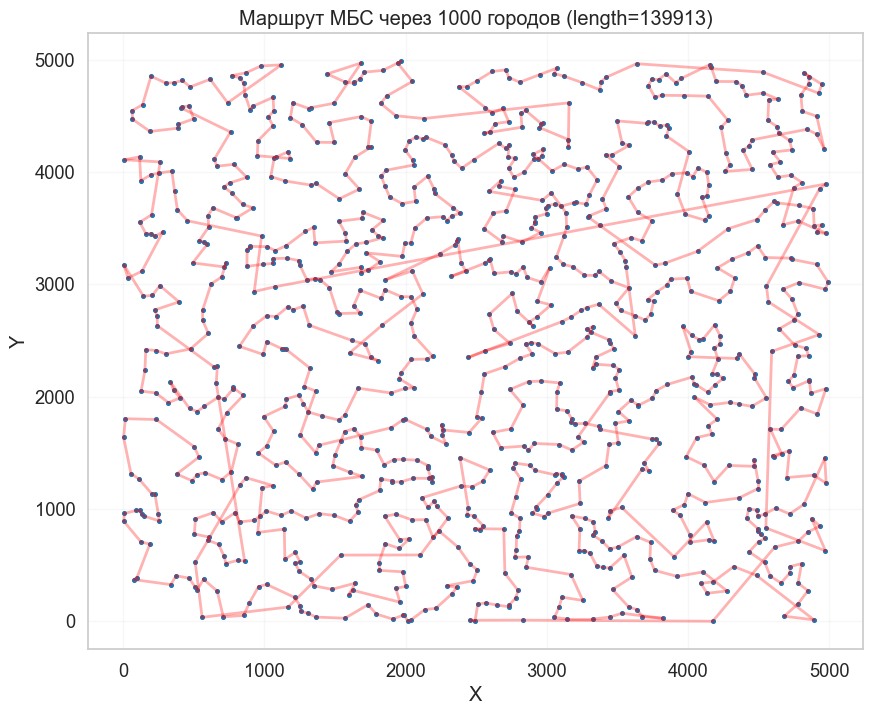

In [121]:
plt.figure(figsize=(10, 8))
plt.scatter(xs, ys, s=7)
for i in range(n_vertices):
    current_node, next_node = nn_cycle[i], nn_cycle[(i+1) % n_vertices]
    x1 = xs[current_node]
    x2 = xs[next_node]
    y1 = ys[current_node]
    y2 = ys[next_node]
    x = (x1, x2)
    y = (y1, y2)
    plt.plot(x, y, color='red', alpha=0.3, linewidth=2)

plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Маршрут МБС через 1000 городов (length={nn_dist})')
plt.grid(True, alpha=0.15)
plt.show()

### 2-opt

In [25]:
def cycle_length(cycle, matrix):
    length = 0
    n = cycle.shape[0]
    for i in range(n):
        node_1, node_2 = cycle[i], cycle[(i+1) % n]
        length += matrix[node_1, node_2]
    return length


def two_opt(cycle, matrix):
    start_time = perf_counter()
    n = cycle.shape[0]
    best_cycle = cycle.copy()
    best_cycle = np.append(best_cycle, cycle[0])
    
    improved = True
    while improved:
        improved = False
        for i in range(n - 2):
            for j in range(i + 2, n):
                node_1, node_2, node_3, node_4 = best_cycle[i], best_cycle[i + 1], best_cycle[j], best_cycle[j + 1]
                delta = -matrix[node_1, node_2] - matrix[node_3, node_4] + matrix[node_1, node_3] + matrix[node_2, node_4]
                if delta < -1e-9:
                    best_cycle[(i+1):(j+1)] = best_cycle[j:i:-1]
                    improved = True
                    break
            if improved:
                break
    best_cycle = best_cycle[:-1]
    best_length = cycle_length(best_cycle, matrix)
    end_time = perf_counter()
    time = (end_time - start_time) * 1000
    return best_cycle, best_length, time

In [101]:
%%time
modernized_cycle, modernized_length, twoopt_time = two_opt(nn_cycle, matrix)

CPU times: total: 3min 16s
Wall time: 3min 17s


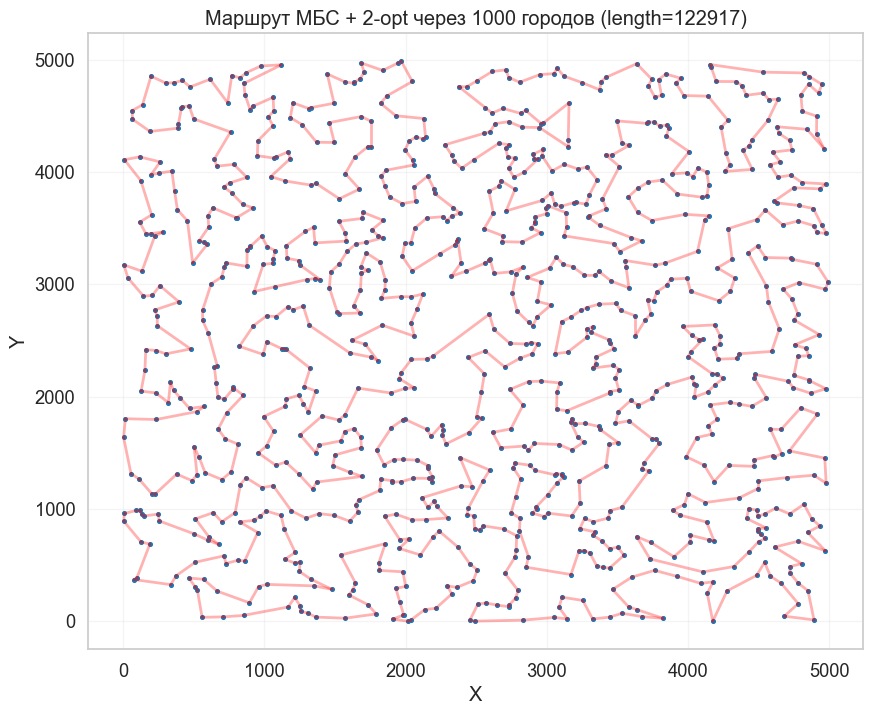

In [102]:
plt.figure(figsize=(10, 8))
plt.scatter(xs, ys, s=7)
for i in range(n_vertices):
    current_node, next_node = modernized_cycle[i], modernized_cycle[(i+1) % n_vertices]
    x1 = xs[current_node]
    x2 = xs[next_node]
    y1 = ys[current_node]
    y2 = ys[next_node]
    x = (x1, x2)
    y = (y1, y2)
    
    plt.plot(x, y, color='red', alpha=0.3, linewidth=2)

plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Маршрут МБС + 2-opt через 1000 городов (length={modernized_length:.0f})')
plt.grid(True, alpha=0.2)
plt.show()

### МБС + АКМ + 2-opt

In [60]:
rs = np.random.RandomState(random_state)

matrix, xs, ys = generate_matrix(n_vertices=100, rs=rs, xy=True)
n_vertices = matrix.shape[0]

In [61]:
%%time
aco_model = AntColony(max_iter=100, random_state=42, stop_iter=17)
aco_model.fit(matrix)
aco_cycle, aco_dist, aco_result, aco_time = aco_model.get()

check_perfomance(aco_dist, aco_time, n_vertices=n_vertices, model_name='Алгоритм колонии муравьев')

=== Алгоритм колонии муравьев ===
Число вершин: 100
Плотность графа: 1.00
Длина найденного цикла: 4448
Время исполнения: 21 c
CPU times: total: 21.8 s
Wall time: 22 s


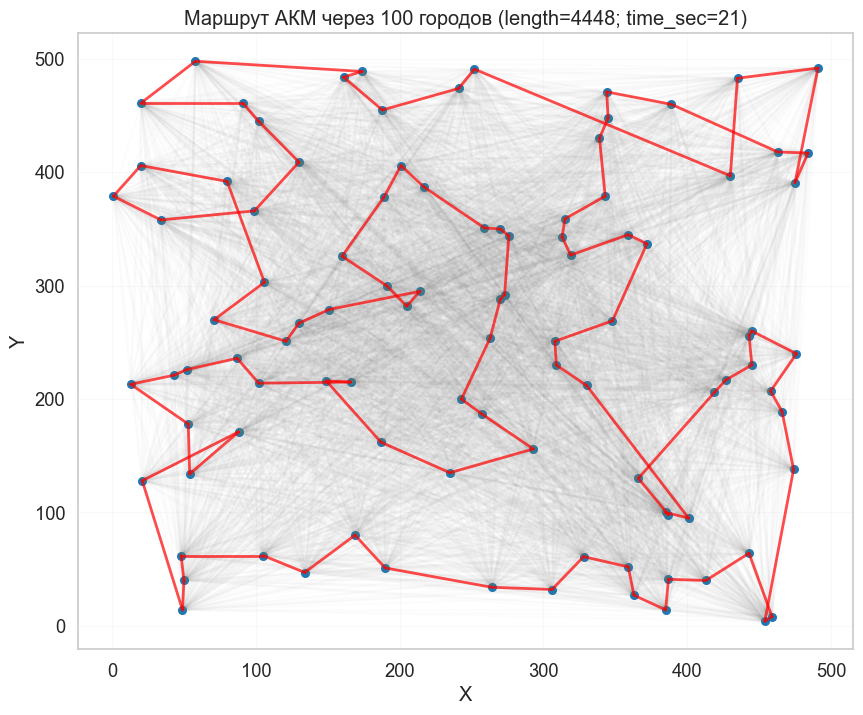

CPU times: total: 4.98 s
Wall time: 5.03 s


In [62]:
%%time
plt.figure(figsize=(10, 8))
plt.scatter(xs, ys, s=30)
  
for i in range(n_vertices):
    for j in range(i+1, n_vertices):
        plt.plot([xs[i], xs[j]], [ys[i], ys[j]], color='gray', alpha=0.02)
        
for i in range(n_vertices):
    current_node, next_node = aco_cycle[i], aco_cycle[(i+1) % n_vertices]
    x1 = xs[current_node]
    x2 = xs[next_node]
    y1 = ys[current_node]
    y2 = ys[next_node]
    x = (x1, x2)
    y = (y1, y2)
    plt.plot(x, y, color='red', alpha=0.7, linewidth=2)

plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Маршрут АКМ через {n_vertices} городов (length={aco_dist:.0f}; time_sec={aco_time // 1000})')
plt.grid(True, alpha=0.1)
plt.show()

In [63]:
nn_model = NearestNeighbor()
nn_model.fit(matrix)
nn_cycle, _, _, _ = nn_model.get()

In [64]:
%%time
aco_model = AntColony(max_iter=100, random_state=42, init_cycle=nn_cycle, stop_iter=17)
aco_model.fit(matrix)
aco_cycle, aco_dist, aco_result, aco_time = aco_model.get()

CPU times: total: 20.2 s
Wall time: 20.5 s


In [65]:
%%time
modernized_cycle, modernized_length, twoopt_time = two_opt(aco_cycle, matrix)

CPU times: total: 62.5 ms
Wall time: 71.2 ms


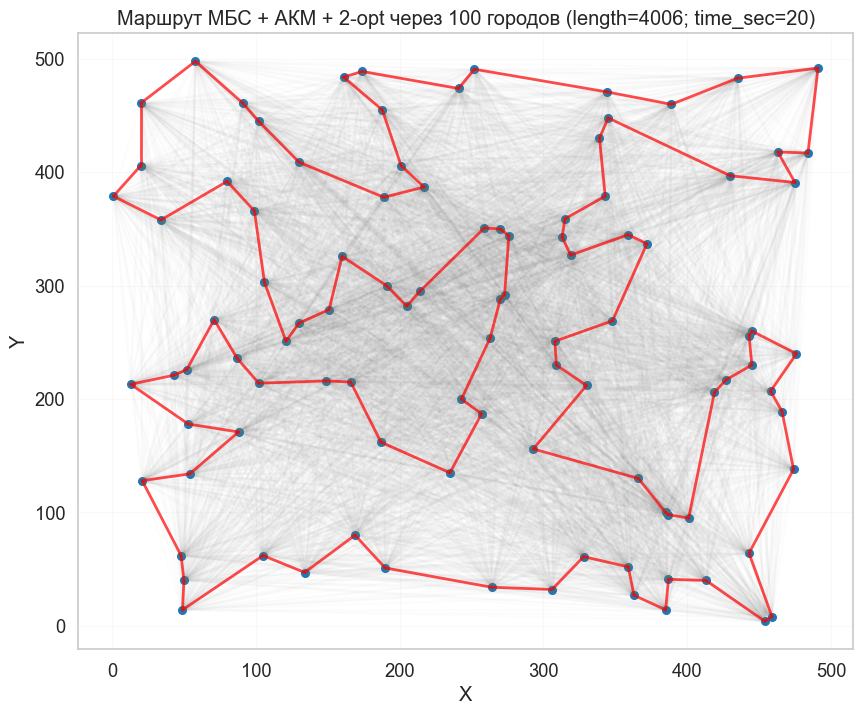

In [66]:
total_time = (nn_time + aco_time + twoopt_time) // 1000

plt.figure(figsize=(10, 8))
plt.scatter(xs, ys, s=30)

for i in range(n_vertices):
    for j in range(i+1, n_vertices):
        plt.plot([xs[i], xs[j]], [ys[i], ys[j]], color='gray', alpha=0.02)

for i in range(n_vertices):
    current_node, next_node = modernized_cycle[i], modernized_cycle[(i+1) % n_vertices]
    x1 = xs[current_node]
    x2 = xs[next_node]
    y1 = ys[current_node]
    y2 = ys[next_node]
    x = (x1, x2)
    y = (y1, y2)
    plt.plot(x, y, color='red', alpha=0.7, linewidth=2)

plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Маршрут МБС + АКМ + 2-opt через {n_vertices} городов (length={modernized_length:.0f}; time_sec={total_time:.0f})')
plt.grid(True, alpha=0.1)
plt.show()

### Точное решение

In [26]:
def elkai_solve(dist_matrix, scale=1000):
    start_time = perf_counter()
    int_matrix = np.round(dist_matrix * scale).astype(int).tolist()
    
    solver = elkai.DistanceMatrix(int_matrix)
    tour = solver.solve_tsp()
    
    if tour[0] == tour[-1]:
        tour = tour[:-1]
    length = sum(dist_matrix[tour[i], tour[i+1]] for i in range(len(tour)-1))
    elapsed_time = (perf_counter() - start_time) * 1000
    return length, elapsed_time

In [27]:
%%time
matrix = generate_matrix(150, rs=np.random.RandomState(42))
elkai_solve(matrix)

CPU times: total: 1.94 s
Wall time: 1.97 s


(np.float64(7067.319243530988), 1910.846899729222)

## Сбор данных

### LKH

In [125]:
random_state = 42
N_nodes = [*list(range(10, 151, 10)), 200, 300, 500]
avg_iter = 20

In [126]:
%%time
graphs = get_data(N_nodes, avg_iter=avg_iter, random_state=random_state)

CPU times: total: 17.2 s
Wall time: 17.4 s


In [294]:
%%time

cell_info = True
lkh_columns = ['Model', 'Nodes', 'Length', 'Time_ms']
lkh_data = pd.DataFrame(columns=etalon_columns)

model_name = 'LKH'
lkh_lengths = []
lkh_time = []

for node_graph in graphs:
    n_vertices = node_graph.shape[1]
    time_list = []
    lengths = []

    for i in range(avg_iter):
        iter_time = perf_counter()
        
        length, time = elkai_solve(node_graph[i])
        time_list.append(time)
        lengths.append(length)
        
        if cell_info:
            print(f'Размерность: {n_vertices}')
            print(f'Итерация: {i}')
            print(f'Время: {perf_counter() - iter_time:.0f}')
            clear_output(wait=True)

    time_arr = np.array(time_list)
    lengths = np.array(lengths, dtype=float)
    
    lkh_lengths.append((n_vertices, lengths))
    lkh_time.append((n_vertices, time_arr))
    
    avg_length = int(np.mean(lengths))
    avg_time = np.mean(time_arr, dtype=int)

    lkh_data.loc[len(lkh_data), :] = [model_name, n_vertices, avg_length, avg_time] 

CPU times: total: 13min 24s
Wall time: 13min 40s


In [295]:
lkh_data

,Model,Nodes,Length,Time_ms
0,LKH,10,130,1
1,LKH,20,370,5
2,LKH,30,679,16
3,LKH,40,992,49
4,LKH,50,1408,77
5,LKH,60,1829,111
6,LKH,70,2273,163
7,LKH,80,2793,314
8,LKH,90,3293,406
9,LKH,100,3877,422


In [296]:
if True:
    lkh_data.to_csv('lkh.csv', index=False)

    with open('lkh_lengths.pkl', 'wb') as f:
        pickle.dump(lkh_lengths, f)
        
    with open('lkh_time.pkl', 'wb') as f:
        pickle.dump(lkh_time, f)

In [297]:
if os.path.exists('lkh.csv'):
    lkh_data_test = pd.read_csv('lkh.csv')

with open('lkh_lengths.pkl', 'rb') as f:
    lkh_len_test = pickle.load(f)
    
with open('lkh_time.pkl', 'rb') as f:
    lkh_time_test = pickle.load(f)

### МБС

In [298]:
%%time
columns = ['Model', 'Nodes', 'Length', 'Percent_error', 'Time_ms']

model_name = 'МБС'
nn_data = pd.DataFrame(columns=columns)
nn_lengths = []
nn_time = []

for idx, node_graph in enumerate(graphs):
    n_vertices = node_graph.shape[1]
    len_tup = lkh_lengths[idx]
    if len_tup[0] == n_vertices:
        etalon_lengths = len_tup[1]
    
    errors = []
    time_list = []
    lengths = []

    for i in range(avg_iter):

        adj_matrix = node_graph[i]

        model = NearestNeighbor()
        model.fit(adj_matrix)
        cycle, dist, result, time = model.get()
        
        error = compute_error(dist, etalon_lengths[i])
        errors.append(error)
        
        time_list.append(time)
        lengths.append(dist)
    
    errors = np.array(errors, dtype=float)
    time_arr = np.array(time_list)
    lengths = np.array(lengths, dtype=float)
    
    nn_lengths.append((n_vertices, lengths))
    nn_time.append((n_vertices, time_arr))

    avg_error = round(np.nanmean(errors), 2)
    avg_length = int(np.nanmean(lengths))

    avg_time = np.mean(time_arr, dtype=int)

    nn_data.loc[len(nn_data), :] = [model_name, n_vertices, avg_length, avg_error, avg_time]

CPU times: total: 1.11 s
Wall time: 1.18 s


In [299]:
nn_data

,Model,Nodes,Length,Percent_error,Time_ms
0,МБС,10,166,27.68,0
1,МБС,20,466,26.1,0
2,МБС,30,841,23.95,0
3,МБС,40,1269,27.75,0
4,МБС,50,1817,29.13,1
5,МБС,60,2334,27.64,1
6,МБС,70,2834,24.79,1
7,МБС,80,3467,24.12,1
8,МБС,90,4133,25.53,1
9,МБС,100,5013,29.31,1


In [300]:
if True:
    nn_data.to_csv('nn.csv', index=False)

    with open('nn_lengths.pkl', 'wb') as f:
        pickle.dump(nn_lengths, f)
        
    with open('nn_time.pkl', 'wb') as f:
        pickle.dump(nn_time, f)

In [301]:
if os.path.exists('nn.csv'):
    nn_data_test = pd.read_csv('nn.csv')

with open('nn_lengths.pkl', 'rb') as f:
    nn_len_test = pickle.load(f)
    
with open('nn_time.pkl', 'rb') as f:
    nn_time_test = pickle.load(f)

### АКМ

In [302]:
%%time
if True:

    aco_data = pd.DataFrame(columns=columns)
    aco_lengths = []
    aco_time = []
    
    cell_info = True
    clear = False

    model_name = 'АКМ'

    start_time = perf_counter()
    for idx, node_graph in enumerate(graphs):
        n_vertices = node_graph.shape[1]
        
        len_tup = lkh_lengths[idx]
        if len_tup[0] == n_vertices:
            etalon_lengths = len_tup[1]
        
        if cell_info:
            print(f'Размерность: {n_vertices} | Прошло времени: {perf_counter() - start_time:.0f}')

        errors = []
        time_list = []
        lengths = []

        for i in range(avg_iter):
            iter_time = perf_counter()

            adj_matrix = node_graph[i]

            model = AntColony(max_iter=100, stop_iter=17)
            model.fit(adj_matrix)
            cycle, dist, result, time = model.get()

            error = compute_error(dist, etalon_lengths[i])
            errors.append(error)
            
            time_list.append(time)
            lengths.append(dist)
            
            if cell_info:
                print(f'\tИтерация: {i} | Время: {perf_counter() - iter_time:.0f}')

        errors = np.array(errors, dtype=float)
        time_arr = np.array(time_list)
        lengths = np.array(lengths, dtype=float)
        
        aco_lengths.append((n_vertices, lengths))
        aco_time.append((n_vertices, time_arr))

        avg_error = round(np.nanmean(errors), 2)
        avg_length = int(np.nanmean(lengths))
        avg_time = np.mean(time_arr, dtype=int)

        aco_data.loc[len(aco_data), :] = [model_name, n_vertices, avg_length, avg_error, avg_time]

Размерность: 10 | Прошло времени: 0
	Итерация: 0 | Время: 0
	Итерация: 1 | Время: 0
	Итерация: 2 | Время: 0
	Итерация: 3 | Время: 0
	Итерация: 4 | Время: 0
	Итерация: 5 | Время: 0
	Итерация: 6 | Время: 0
	Итерация: 7 | Время: 0
	Итерация: 8 | Время: 0
	Итерация: 9 | Время: 0
	Итерация: 10 | Время: 0
	Итерация: 11 | Время: 0
	Итерация: 12 | Время: 0
	Итерация: 13 | Время: 0
	Итерация: 14 | Время: 0
	Итерация: 15 | Время: 0
	Итерация: 16 | Время: 0
	Итерация: 17 | Время: 0
	Итерация: 18 | Время: 0
	Итерация: 19 | Время: 0
Размерность: 20 | Прошло времени: 5
	Итерация: 0 | Время: 2
	Итерация: 1 | Время: 2
	Итерация: 2 | Время: 1
	Итерация: 3 | Время: 1
	Итерация: 4 | Время: 1
	Итерация: 5 | Время: 2
	Итерация: 6 | Время: 1
	Итерация: 7 | Время: 1
	Итерация: 8 | Время: 1
	Итерация: 9 | Время: 1
	Итерация: 10 | Время: 1
	Итерация: 11 | Время: 1
	Итерация: 12 | Время: 2
	Итерация: 13 | Время: 2
	Итерация: 14 | Время: 1
	Итерация: 15 | Время: 2
	Итерация: 16 | Время: 1
	Итерация: 17 | Время: 

	Итерация: 1 | Время: 113
	Итерация: 2 | Время: 101
	Итерация: 3 | Время: 119
	Итерация: 4 | Время: 72
	Итерация: 5 | Время: 133
	Итерация: 6 | Время: 60
	Итерация: 7 | Время: 97
	Итерация: 8 | Время: 127
	Итерация: 9 | Время: 88
	Итерация: 10 | Время: 78
	Итерация: 11 | Время: 72
	Итерация: 12 | Время: 66
	Итерация: 13 | Время: 92
	Итерация: 14 | Время: 90
	Итерация: 15 | Время: 70
	Итерация: 16 | Время: 57
	Итерация: 17 | Время: 113
	Итерация: 18 | Время: 66
	Итерация: 19 | Время: 84
Размерность: 300 | Прошло времени: 8705
	Итерация: 0 | Время: 162
	Итерация: 1 | Время: 205
	Итерация: 2 | Время: 201
	Итерация: 3 | Время: 273
	Итерация: 4 | Время: 316
	Итерация: 5 | Время: 211
	Итерация: 6 | Время: 187
	Итерация: 7 | Время: 222
	Итерация: 8 | Время: 183
	Итерация: 9 | Время: 220
	Итерация: 10 | Время: 192
	Итерация: 11 | Время: 215
	Итерация: 12 | Время: 192
	Итерация: 13 | Время: 240
	Итерация: 14 | Время: 255
	Итерация: 15 | Время: 626
	Итерация: 16 | Время: 321
	Итерация: 17 | Врем

In [303]:
aco_data

,Model,Nodes,Length,Percent_error,Time_ms
0,АКМ,10,145,11.84,240
1,АКМ,20,395,6.77,1281
2,АКМ,30,711,4.87,2674
3,АКМ,40,1052,6.06,5108
4,АКМ,50,1494,6.12,8679
5,АКМ,60,1945,6.3,13383
6,АКМ,70,2487,9.42,15602
7,АКМ,80,3035,8.64,21577
8,АКМ,90,3615,9.75,31267
9,АКМ,100,4338,11.9,33877


In [304]:
if True:
    aco_data.to_csv(f'aco.csv', index=False)

    with open('aco_lengths.pkl', 'wb') as f:
        pickle.dump(aco_lengths, f)
        
    with open('aco_time.pkl', 'wb') as f:
        pickle.dump(aco_time, f)

In [305]:
if os.path.exists(f'aco.csv'):
    aco_data_test = pd.read_csv(f'aco.csv')

with open('aco_lengths.pkl', 'rb') as f:
    aco_len_test = pickle.load(f)
    
with open('aco_time.pkl', 'rb') as f:
    aco_time_test = pickle.load(f)

### МБС + АКМ + 2-opt

In [306]:
%%time
if True:

    hybrid_data = pd.DataFrame(columns=columns)
    hybrid_lengths = []
    hybrid_time = []
    
    cell_info = True
    clear = False

    model_name = 'МБС + АКМ + 2-opt'

    start_time = perf_counter()
    for idx, node_graph in enumerate(graphs):
        n_vertices = node_graph.shape[1]
        
        len_tup = lkh_lengths[idx]
        if len_tup[0] == n_vertices:
            etalon_lengths = len_tup[1]
        
        if cell_info:
            print(f'Nodes: {n_vertices} | Passed: {perf_counter() - start_time:.0f}')

        errors = []
        time_list = []
        lengths = []

        for i in range(avg_iter):

            adj_matrix = node_graph[i]
            
            nn_model = NearestNeighbor()
            nn_model.fit(adj_matrix)
            nn_cycle, nn_dist, nn_result, nn_time_val = nn_model.get()
            
            aco_model = AntColony(max_iter=100, stop_iter=17, init_cycle=nn_cycle)
            aco_model.fit(adj_matrix)
            aco_cycle, aco_dist, aco_result, aco_time_val = aco_model.get()
            
            modernized_cycle, modernized_dist, twoopt_time = two_opt(aco_cycle, adj_matrix)
                
            total_time = nn_time_val + aco_time_val + twoopt_time
            
            error = compute_error(modernized_dist, etalon_lengths[i])
            errors.append(error)
            
            time_list.append(total_time)
            lengths.append(modernized_dist)

        errors = np.array(errors, dtype=float)
        time_arr = np.array(time_list)
        lengths = np.array(lengths, dtype=float)
        
        hybrid_lengths.append((n_vertices, lengths))
        hybrid_time.append((n_vertices, time_arr))

        avg_error = round(np.nanmean(errors), 2)
        avg_length = int(np.nanmean(lengths))
        avg_time = np.mean(time_arr, dtype=int)

        hybrid_data.loc[len(hybrid_data), :] = [model_name, n_vertices, avg_length, avg_error, avg_time]

Nodes: 10 | Passed: 0
Nodes: 20 | Passed: 2
Nodes: 30 | Passed: 10
Nodes: 40 | Passed: 33
Nodes: 50 | Passed: 93
Nodes: 60 | Passed: 192
Nodes: 70 | Passed: 343
Nodes: 80 | Passed: 597
Nodes: 90 | Passed: 907
Nodes: 100 | Passed: 1334
Nodes: 110 | Passed: 1847
Nodes: 120 | Passed: 2404
Nodes: 130 | Passed: 3132
Nodes: 140 | Passed: 3923
Nodes: 150 | Passed: 4757
Nodes: 200 | Passed: 5713
Nodes: 300 | Passed: 7490
Nodes: 500 | Passed: 10966
CPU times: total: 5h 1min 19s
Wall time: 5h 1min 20s


In [307]:
hybrid_data

,Model,Nodes,Length,Percent_error,Time_ms
0,МБС + АКМ + 2-opt,10,146,12.76,107
1,МБС + АКМ + 2-opt,20,398,7.65,398
2,МБС + АКМ + 2-opt,30,719,6.01,1148
3,МБС + АКМ + 2-opt,40,1049,5.74,2973
4,МБС + АКМ + 2-opt,50,1484,5.42,4955
5,МБС + АКМ + 2-opt,60,1928,5.46,7571
6,МБС + АКМ + 2-opt,70,2385,4.91,12669
7,МБС + АКМ + 2-opt,80,2910,4.19,15527
8,МБС + АКМ + 2-opt,90,3445,4.6,21329
9,МБС + АКМ + 2-opt,100,4098,5.72,25651


In [308]:
if True:
    hybrid_data.to_csv(f'hybrid.csv', index=False)

    with open('hybrid_lengths.pkl', 'wb') as f:
        pickle.dump(hybrid_lengths, f)
        
    with open('hybrid_time.pkl', 'wb') as f:
        pickle.dump(hybrid_time, f)

In [309]:
if os.path.exists(f'hybrid.csv'):
    hybrid_data_test = pd.read_csv(f'hybrid.csv')

with open('hybrid_lengths.pkl', 'rb') as f:
    hybrid_len_test = pickle.load(f)
    
with open('hybrid_time.pkl', 'rb') as f:
    hybrid_time_test = pickle.load(f)

### Сходимость

In [127]:
cell_info = True
graph_100 = graphs[9][16]
convergence_iterations = [5, 10, 15, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200]
aco_hybrid_100 = []

lkh_length_100, _ = elkai_solve(graph_100)

In [102]:
%%time



start_time = perf_counter()
for conv_iter in convergence_iterations:
    if cell_info:
        print(f'Итераций для сходимости: {conv_iter} | Прошло времени: {perf_counter() - start_time:.0f}')
    aco_arr = []
    hybrid_arr = []
    
    for i in range(avg_iter):
        
        iter_time = perf_counter()

        model = AntColony(max_iter=conv_iter, stop_iter=conv_iter)
        model.fit(graph_100)
        cycle, dist, result, time = model.get()

        nn_model = NearestNeighbor()
        nn_model.fit(graph_100)
        nn_cycle, nn_dist, nn_result, nn_time_val = nn_model.get()

        aco_model = AntColony(max_iter=conv_iter, stop_iter=conv_iter, init_cycle=nn_cycle)
        aco_model.fit(graph_100)
        aco_cycle, aco_dist, aco_result, aco_time_val = aco_model.get()

        modernized_cycle, modernized_dist, twoopt_time = two_opt(aco_cycle, graph_100)
        
        aco_arr.append(dist)
        hybrid_arr.append(modernized_dist)
        
        if cell_info:
            print(f'\tИтерация: {i} | Время: {perf_counter() - iter_time:.0f}')
    
    mean_aco_dist = int(np.mean(aco_arr))
    mean_hybrid_dist = int(np.mean(hybrid_arr))
    
    aco_hybrid_100.append((conv_iter, mean_aco_dist, mean_hybrid_dist))

Итераций для сходимости: 5 | Прошло времени: 0
	Итерация: 0 | Время: 10
	Итерация: 1 | Время: 10
	Итерация: 2 | Время: 11
	Итерация: 3 | Время: 10
	Итерация: 4 | Время: 10
	Итерация: 5 | Время: 10
	Итерация: 6 | Время: 11
	Итерация: 7 | Время: 10
	Итерация: 8 | Время: 9
	Итерация: 9 | Время: 9
	Итерация: 10 | Время: 9
	Итерация: 11 | Время: 9
	Итерация: 12 | Время: 9
	Итерация: 13 | Время: 9
	Итерация: 14 | Время: 9
	Итерация: 15 | Время: 10
	Итерация: 16 | Время: 9
	Итерация: 17 | Время: 9
	Итерация: 18 | Время: 9
	Итерация: 19 | Время: 10
Итераций для сходимости: 10 | Прошло времени: 192
	Итерация: 0 | Время: 19
	Итерация: 1 | Время: 19
	Итерация: 2 | Время: 18
	Итерация: 3 | Время: 17
	Итерация: 4 | Время: 18
	Итерация: 5 | Время: 17
	Итерация: 6 | Время: 18
	Итерация: 7 | Время: 18
	Итерация: 8 | Время: 18
	Итерация: 9 | Время: 18
	Итерация: 10 | Время: 18
	Итерация: 11 | Время: 18
	Итерация: 12 | Время: 19
	Итерация: 13 | Время: 18
	Итерация: 14 | Время: 18
	Итерация: 15 | Время: 

In [103]:
with open('convergence.pkl', 'wb') as f:
    pickle.dump(aco_hybrid_100, f)

## Графики

In [28]:
with open('convergence.pkl', 'rb') as f:
    aco_hybrid_100 = pickle.load(f)

    
    
with open('nn_lengths.pkl', 'rb') as f:
    nn_lengths = pickle.load(f)
    
with open('aco_lengths.pkl', 'rb') as f:
    aco_lengths = pickle.load(f)
    
with open('hybrid_lengths.pkl', 'rb') as f:
    hybrid_lengths = pickle.load(f)
    
with open('lkh_lengths.pkl', 'rb') as f:
    lkh_lengths = pickle.load(f)
    
    
    
with open('nn_time.pkl', 'rb') as f: 
    nn_time = pickle.load(f)
    
with open('aco_time.pkl', 'rb') as f:
    aco_time = pickle.load(f)
    
with open('hybrid_time.pkl', 'rb') as f:
    hybrid_time = pickle.load(f)
    
with open('lkh_time.pkl', 'rb') as f:
    lkh_time = pickle.load(f)
    
    
nn_data = pd.read_csv('nn.csv')
aco_data = pd.read_csv('aco.csv')
hybrid_data = pd.read_csv('hybrid.csv')
lkh_data = pd.read_csv('lkh.csv')

### Сходимость

In [137]:
aco_len_100 = []
hybrid_len_100 = []
conv_iters_100 = []

for it, aco_l, hybrid_l in aco_hybrid_100:
    aco_len_100.append(aco_l)
    hybrid_len_100.append(hybrid_l)
    conv_iters_100.append(it)

In [170]:
pd.DataFrame([aco_len_100, hybrid_len_100, conv_iters_100])

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,4952,4751,4628,4624,4501,4453,4409,4425,4389,4384,4375,4354,4358
1,4244,4248,4221,4238,4200,4218,4194,4201,4167,4202,4178,4183,4185
2,5,10,15,20,40,60,80,100,120,140,160,180,200


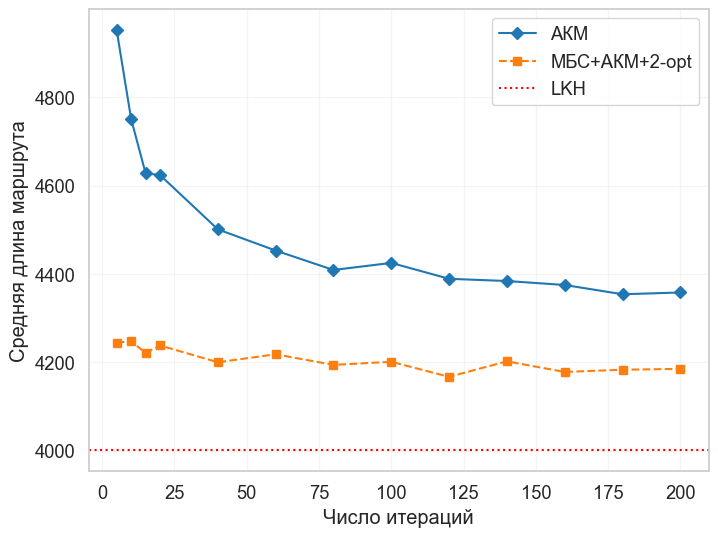

In [168]:
plt.plot(conv_iters_100, aco_len_100, '-D', label='АКМ')
plt.plot(conv_iters_100, hybrid_len_100, '--s', label='МБС+АКМ+2-opt')
plt.xlabel('Число итераций')
plt.ylabel('Средняя длина маршрута')
# plt.title('Сходимость алгоритмов на графе из 100 вершин')
plt.axhline(lkh_length_100, linestyle=':', color='red', label='LKH')
plt.legend(loc='best')
plt.grid(True, alpha=0.2)
plt.show()

### Boxplot

In [139]:
nn_errors = []
aco_errors = []
hybrid_errors = []

for i in range(len(N_nodes)):
    for j in range(avg_iter):
        nn_err = compute_error(nn_lengths[i][1][j], lkh_lengths[i][1][j])
        aco_err = compute_error(aco_lengths[i][1][j], lkh_lengths[i][1][j])
        hybrid_err = compute_error(hybrid_lengths[i][1][j], lkh_lengths[i][1][j])
        
        nn_errors.append(nn_err)
        aco_errors.append(aco_err)
        hybrid_errors.append(hybrid_err)

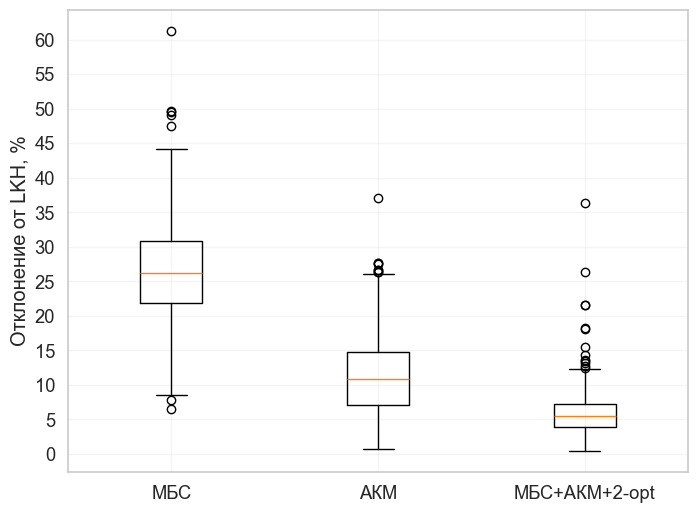

In [140]:
all_errors = [nn_errors, aco_errors, hybrid_errors]
plt.boxplot(all_errors, tick_labels=['МБС', 'АКМ', 'МБС+АКМ+2-opt'])
plt.ylabel('Отклонение от LKH, %')
plt.locator_params(axis='y', nbins=20)
plt.grid(True, alpha=0.2)
plt.show()

### Лучшее, среднее, худшее время

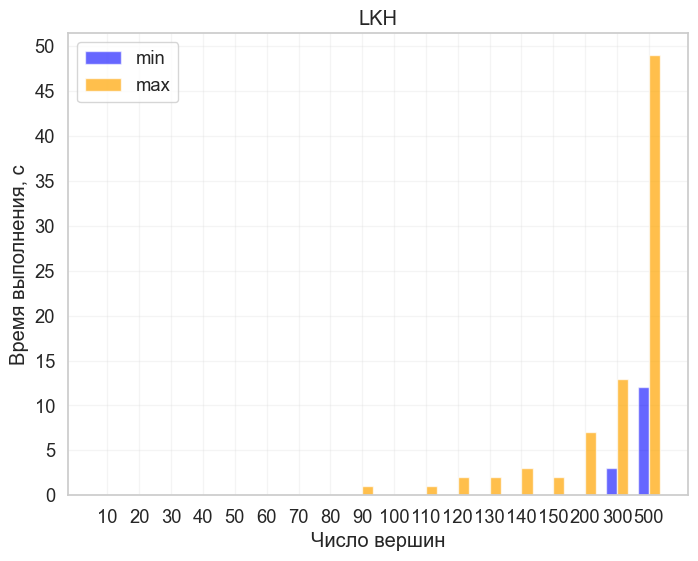

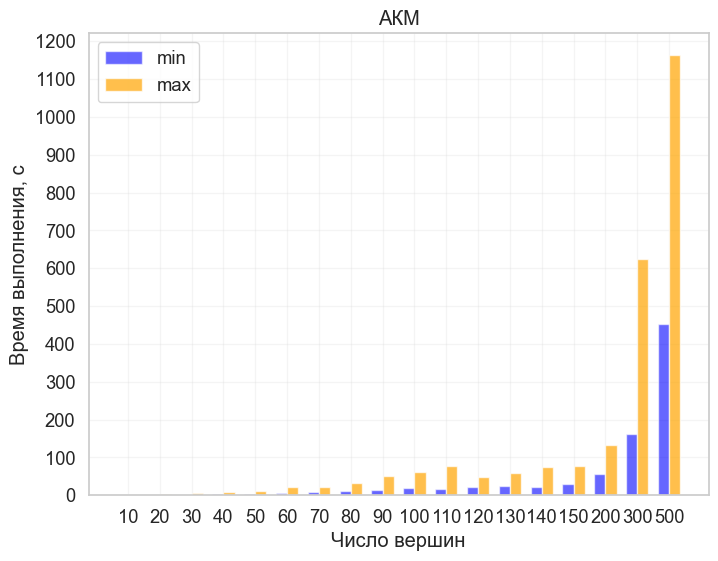

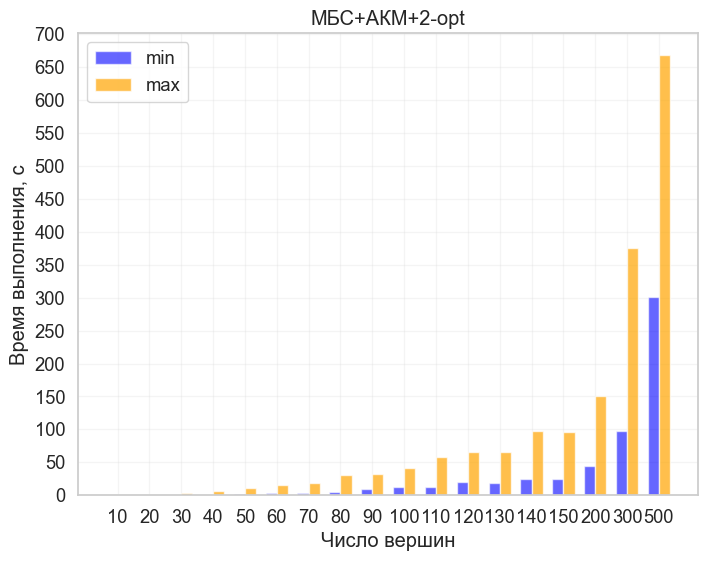

In [41]:
all_time = [lkh_time, aco_time, hybrid_time]
names = ['LKH', 'АКМ', 'МБС+АКМ+2-opt']

for idx, model_time in enumerate(all_time):
    
    x = [tup[0] for tup in model_time] 
    min_vals = [np.min(tup[1]) // 1000 for tup in model_time]
    max_vals = [np.max(tup[1]) // 1000 for tup in model_time]

    width = 0.35                     
    x_pos = np.arange(len(x))  

    plt.bar(x_pos - width/2, min_vals, width, label='min', alpha=0.6, color='blue')
    plt.bar(x_pos + width/2, max_vals, width, label='max', alpha=0.7, color='orange')
    
    plt.xticks(x_pos, x)        
    plt.xlabel('Число вершин')
    plt.ylabel('Время выполнения, c')
    plt.locator_params(axis='y', nbins=15)
    plt.title(f'{names[idx]}')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

In [37]:
nn_data

,Model,Nodes,Length,Percent_error,Time_ms
0,МБС,10,166,27.68,0
1,МБС,20,466,26.10,0
2,МБС,30,841,23.95,0
3,МБС,40,1269,27.75,0
4,МБС,50,1817,29.13,1
5,МБС,60,2334,27.64,1
6,МБС,70,2834,24.79,1
7,МБС,80,3467,24.12,1
8,МБС,90,4133,25.53,1
9,МБС,100,5013,29.31,1


In [36]:
aco_data

,Model,Nodes,Length,Percent_error,Time_ms
0,АКМ,10,145,11.84,240
1,АКМ,20,395,6.77,1281
2,АКМ,30,711,4.87,2674
3,АКМ,40,1052,6.06,5108
4,АКМ,50,1494,6.12,8679
5,АКМ,60,1945,6.30,13383
6,АКМ,70,2487,9.42,15602
7,АКМ,80,3035,8.64,21577
8,АКМ,90,3615,9.75,31267
9,АКМ,100,4338,11.90,33877


In [38]:
hybrid_data

,Model,Nodes,Length,Percent_error,Time_ms
0,МБС + АКМ + 2-opt,10,146,12.76,107
1,МБС + АКМ + 2-opt,20,398,7.65,398
2,МБС + АКМ + 2-opt,30,719,6.01,1148
3,МБС + АКМ + 2-opt,40,1049,5.74,2973
4,МБС + АКМ + 2-opt,50,1484,5.42,4955
5,МБС + АКМ + 2-opt,60,1928,5.46,7571
6,МБС + АКМ + 2-opt,70,2385,4.91,12669
7,МБС + АКМ + 2-opt,80,2910,4.19,15527
8,МБС + АКМ + 2-opt,90,3445,4.60,21329
9,МБС + АКМ + 2-opt,100,4098,5.72,25651


In [39]:
lkh_data

,Model,Nodes,Length,Time_ms
0,LKH,10,130,1
1,LKH,20,370,5
2,LKH,30,679,16
3,LKH,40,992,49
4,LKH,50,1408,77
5,LKH,60,1829,111
6,LKH,70,2273,163
7,LKH,80,2793,314
8,LKH,90,3293,406
9,LKH,100,3877,422


### Средняя длина, время

In [145]:
lkh_len_ = lkh_data['Length']
nn_len_ = nn_data['Length']
aco_len_ = aco_data['Length']
hybrid_len_ = hybrid_data['Length']

lkh_time_ = lkh_data['Time_ms']
nn_time_ = nn_data['Time_ms']
aco_time_ = aco_data['Time_ms']
hybrid_time_ = hybrid_data['Time_ms']

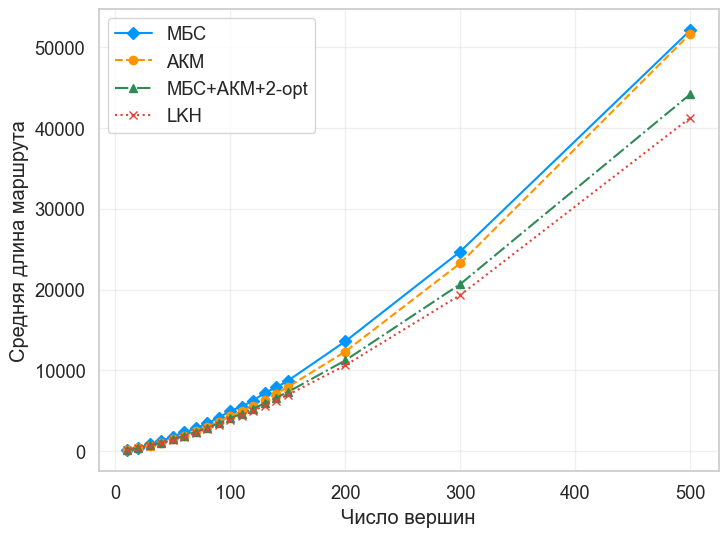

In [151]:
plt.figure(figsize=(8, 6))
colors = ['#0096FF', '#FF9300', '#2E8B57', '#E34234']

plt.plot(N_nodes, nn_len_, '-D', color=colors[0], label='МБС')
plt.plot(N_nodes, aco_len_, '--o', color=colors[1], label='АКМ')
plt.plot(N_nodes, hybrid_len_, '-.^', color=colors[2], label='МБС+АКМ+2-opt')
plt.plot(N_nodes, lkh_len_, ':x', color=colors[3], label='LKH')

plt.xlabel('Число вершин')
plt.ylabel('Средняя длина маршрута')
plt.grid(True, alpha=0.3)

plt.legend()
plt.show()

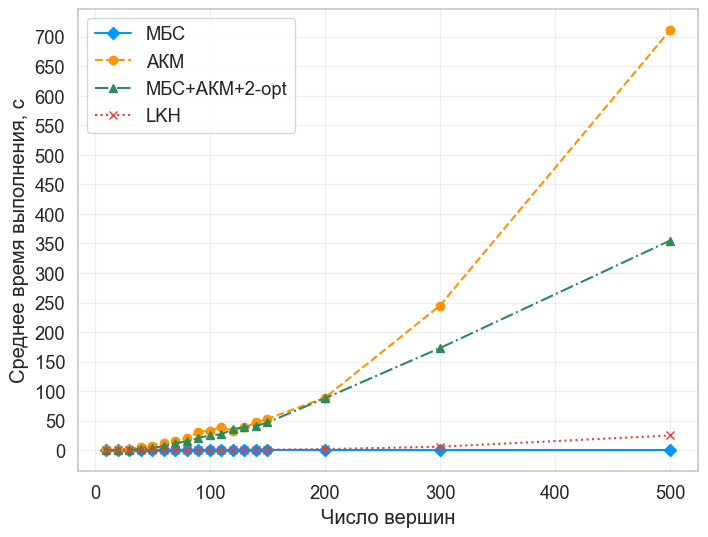

In [152]:
plt.figure(figsize=(8, 6))
colors = ['#0096FF', '#FF9300', '#2E8B57', '#E34234']

plt.plot(N_nodes, nn_time_ // 1000, '-D', color=colors[0], label='МБС')
plt.plot(N_nodes, aco_time_ // 1000, '--o', color=colors[1], label='АКМ')
plt.plot(N_nodes, hybrid_time_ // 1000, '-.^', color=colors[2], label='МБС+АКМ+2-opt')
plt.plot(N_nodes, lkh_time_ // 1000, ':x', color=colors[3], label='LKH')

plt.xlabel('Число вершин')
plt.ylabel('Среднее время выполнения, с')
plt.locator_params(axis='y', nbins=20)
plt.grid(True, alpha=0.3)

plt.legend()
plt.show()